# Assignment 6

<font size = "5">

Import the "pandas" and "matplotlib.pyplot" libraries (and any other libraries if you would like)

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt


<font size = "5">

(a) Functions

<font size = "3">

- Read in the dataset named "features.csv".
- Create a ``` lambda ``` function that checks if weight $≤$ 3000
- Using the Pandas method ``.apply()``, create a new Series that shows ``True`` if weight $≤$ 3000 and ``False``if weight > 3000.
- Using the ``.shape`` attribute, print the number of cars that have weight $≤$ 3000.

**Hint**: A Pandas Series has only one dimension, so the ``.shape`` attribute is a "tuple" with only one element. In order to get a single integer, type ``your_variable_name.shape[0]``


In [ ]:
# Write your answer here:
features = pd.read_csv("data/features.csv")
weight_leq_3000 = features["weight"].apply(lambda wt: wt <= 3000)
print(weight_leq_3000)

num_lightweight = weight_leq_3000[weight_leq_3000].shape[0]
print(f"Number of cars with weight <= 3000: {num_lightweight}")


0      False
1      False
2      False
3      False
4      False
       ...  
393     True
394     True
395     True
396     True
397     True
Name: weight, Length: 398, dtype: bool
Number of cars with weight <= 3000: 230


<font size = "5">

(b) Subsetting Data

<font size = "3" >

- Read in the dataset named "features.csv".
- Define a global variable called ```threshold``` that takes the <br>
value 2500
- Subset the data to get one dataset with weight $>$ threshold and <br>
another with weight $\le$ threshold. Use the ```.query()``` function.
- Compute the mean acceleration for each of these datasets, printing these values to the screen<br>

Note: Review how to define a global variable inside ```.query()```
 

In [3]:
# Subset by a weight threshold and compare mean acceleration
features = pd.read_csv("data/features.csv")
threshold = 2500
heavier = features.query("weight > @threshold")
lighter = features.query("weight <= @threshold")

print(f"Mean acceleration (weight > {threshold}): {heavier['acceleration'].mean():.2f}")
print(f"Mean acceleration (weight <= {threshold}): {lighter['acceleration'].mean():.2f}")


Mean acceleration (weight > 2500): 15.00
Mean acceleration (weight <= 2500): 16.54


<font size = "5">

(c) Use sorting + ".iloc[]"

<font size = "3">

- Read the "fifa23_players_basic.csv" dataset
- Use ".sort_values()" to order the "Age" column <br>
from oldest to youngest
- Get a subset with the 5 oldest players

In [ ]:
# Write your answer here:
fifa = pd.read_csv("data/fifa23_players_basic.csv")
fifa_sorted = fifa.sort_values(by="Age", ascending=False)
oldest_five = fifa_sorted.iloc[:5, :]
print(oldest_five)


           Known As            Full Name  Overall  Potential  Value(in Euro)  \
592       G. Buffon     Gianluigi Buffon       79         79         1900000   
3276     S. Torrico    Sebastián Torrico       72         72          250000   
13548      S. Lukić         Stojan Lukić       62         62           45000   
10851     M. Galezo        Moisés Galezo       64         64               0   
2423   Rubén Castro  Rubén Castro Martín       73         73               0   

      Positions Played Best Position             Nationality  \
592                 GK            GK                   Italy   
3276                GK            GK               Argentina   
13548               GK            GK  Bosnia and Herzegovina   
10851               CB            CB               Venezuela   
2423                ST            ST                   Spain   

                                             Image Link  Age  ...  \
592    https://cdn.sofifa.net/players/001/179/23_60.png   44  ...

<font size = "5">

(d) Use queries + global variables

<font size = "3">

- Read the "fifa23_players_basic.csv" dataset
- Compute the mean of the column "Weight(in kg)"
and store it as a variable
- Subset the players whose Weight in kilograms is stricly large than this mean value
  using ".query()"


HINT: Remember that there is a special syntax for when using column names inside the .query() method (the backtick `)

In [ ]:
# Write your answer here:
fifa = pd.read_csv("data/fifa23_players_basic.csv")
mean_weight = fifa["Weight(in kg)"].mean()
print(f"Mean weight: {mean_weight:.2f} kg")
heavier_players = fifa.query("`Weight(in kg)` > @mean_weight")
print(heavier_players.head())


Mean weight: 75.17 kg
            Known As                     Full Name  Overall  Potential  \
1         K. Benzema                 Karim Benzema       91         91   
2     R. Lewandowski            Robert Lewandowski       91         91   
6        T. Courtois              Thibaut Courtois       90         91   
7           M. Neuer                  Manuel Neuer       90         90   
8  Cristiano Ronaldo  C. Ronaldo dos Santos Aveiro       90         90   

   Value(in Euro) Positions Played Best Position Nationality  \
1        64000000            CF,ST            CF      France   
2        84000000               ST            ST      Poland   
6        90000000               GK            GK     Belgium   
7        13500000               GK            GK     Germany   
8        41000000               ST            ST    Portugal   

                                         Image Link  Age  ...  Preferred Foot  \
1  https://cdn.sofifa.net/players/165/153/23_60.png   34  ...      

<font size = "5">

(e) Plot by Category

<font size = "3">

Read in the dataset named "wdi_urban.csv".

  This contains data from 1980 and 2020.

- **Create an array with the unique values of "year" using the ``Pandas`` function ``unique``**

- **Create a plot with a ...**
    - Histogram of "prop_urbanpopulation" (proportion of urban population) for each year
    - Set the histogram option `alpha = 0.5` for transparency
    - All the histograms should be overlapping on the same plot
    - Create a legend with the list of years
    - Label the axes and the title

**Hint**: The procedure will be similar (but not exactly the same!) as when we created a scatter plot of cars with different numbers of cylinders in Lecture 11

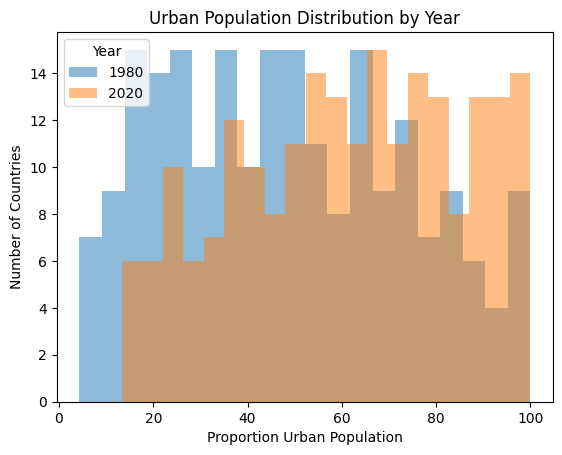

In [ ]:
# your answer here
wdi = pd.read_csv("data/wdi_urban.csv")
unique_years = pd.unique(wdi["year"])

plt.figure()
for year in unique_years:
    subset = wdi.query("year == @year")
    plt.hist(subset["prop_urbanpopulation"], bins=20, alpha=0.5, label=str(year))

plt.xlabel("Proportion Urban Population")
plt.ylabel("Number of Countries")
plt.title("Urban Population Distribution by Year")
plt.legend(title="Year")
plt.show()
